# 03 — Frequency-Domain Coupling (main η analysis)

The central analysis: ground-to-cable strain-transfer FRFs from Welch spectra,
with **four estimators** (direct, H1, H2, Hv), coherence gating, and the
η-vs-Θ summary across all configurations.

### Signals (full sweep record, displacement [m])

| Signal | Definition | Role |
|---|---|---|
| $X(t)=\delta L(t)$ | endpoint-pair span change $u_\parallel(\mathrm{right})-u_\parallel(\mathrm{left})$ (default; or shaker) | input |
| $Y_1(t)=\delta x_\ell(t)$ | Σ per-segment 3-D arc-length elongation | axial output → η |
| $Y_2(t)=u_{\perp,\mathrm{mid}}(t)$ | midpoint displacement ⊥ chord, signed along static sag | bending output |

### Estimators (Welch: nperseg = 2·fs → Δf = 0.5 Hz, 50 % overlap, Hann)

$$H_1=\frac{S_{XY}}{S_{XX}},\qquad H_2=\frac{S_{YY}}{S_{YX}},\qquad
H_v:\ \text{total least squares},\qquad
H_\mathrm{direct}=\frac{\mathcal F\{Y\}}{\mathcal F\{X\}}$$

$|H_1|\le|H_\mathrm{true}|\le|H_2|$ and $\gamma^2=|H_1|/|H_2|$ — the
spread between H1 and H2 widens exactly where coherence drops.

| § | Content |
|---|---|
| 1 | Selection, loading, geometry, signals |
| 2 | Transfer functions (all estimators) + resonance summary |
| 3 | Four-panel FRF figure (wrapped phase) |
| 4 | Estimator comparison H1 / H2 / Hv / direct |
| 5 | STFT-per-frequency cross-check |
| 6 | η vs Θ across ALL configurations (batch) |
| 7 | Export → `results/freqdomain_frf.npz`, `results/freqdomain_eta.npz` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

65 datasets in catalogue.


---
## § 1  Selection, loading, geometry, signals

In [ ]:
from ldv_analysis import freqdomain

# Overlay 2–4 datasets spanning a range of Θ for the FRF figures.
#ACTIVE_LABELS = ["C1_10cm", "C1_10cm_Sag"]
# ACTIVE_LABELS = ["C1_5cm", "C1_10cm", "C1_15cm"]   # gap sweep

# All  datasets for 5 cm without sag
ACTIVE_LABELS = ["C1_5cm", "C2_5cm", "C3_5cm", "C4_5cm", "C5_5cm", "C6_5cm", "C7_5cm"]

X_SOURCE = 'ends'      # 'ends' (recommended) | 'shaker' | 'left_sensor'
ESTIMATOR = None       # primary FRF for the η summaries:
                       #   'h1' | 'h2' | 'hv'  → averaged Welch estimators (Δf = 0.5 Hz)
                       #   None / 'direct'     → raw Y(f)/X(f), no averaging,
                       #                         dense full-record grid (Δf ≈ 0.08 Hz)

DATASETS = config.select_datasets(ACTIVE_LABELS)
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    print(f"  {cfg['label']:20s} Θ={cfg['theta_pred']:.4g}  "
          f"η_pred={cfg['eta_pred']:.3f}")

---
## § 2  Transfer functions & resonance summary

`compute_transfer_functions(..., all_estimators=True)` stores the primary
H_eta/H_mid (chosen `ESTIMATOR`) **and** every variant
(`H_eta_h1/h2/hv`, `H_eta_direct` on the dense FFT grid).

With `ESTIMATOR = None` (or `'direct'`) the primary H is the un-averaged
ratio $\mathcal F\{Y\}/\mathcal F\{X\}$ and `tf['f']` **is** the dense grid
(Δf = fs/N ≈ 0.08 Hz instead of 0.5 Hz). γ² is meaningless for a single
realisation, so the Welch coherence is interpolated onto that grid and used
purely as the quality gate — it never enters H. The Welch grid stays available
as `f_welch` / `coh_eta_welch`; use `freqdomain.frf_arrays(tf, key)` to get the
grid belonging to any given key.

In [ ]:
RES_FMAX = 300.0

rows = []
for cfg in DATASETS:
    # f1/Q come from an AVERAGED FRF: resonance_summary picks the peak with a
    # single-bin argmax, which on the un-averaged direct grid would latch onto
    # a noise spike. The η summaries still use ESTIMATOR (below).
    tf_res = freqdomain.compute_transfer_functions(cfg, estimator='h1',
                                                  all_estimators=False)
    r = freqdomain.resonance_summary(cfg, tf_res, f_max=RES_FMAX)

    # Primary tf — this is the one left in cfg['fd_tf'] for everything after.
    tf = freqdomain.compute_transfer_functions(cfg, estimator=ESTIMATOR,
                                               all_estimators=True)
    rows.append(dict(dataset=r['label'], Theta=round(cfg['theta_pred'], 4),
                     eta_pred=round(cfg['eta_pred'], 3),
                     f1_meas_Hz=round(r['f1_meas'], 1),
                     Q=round(r['Q'], 2) if np.isfinite(r['Q']) else None,
                     zeta=round(r['zeta'], 4) if np.isfinite(r['zeta']) else None,
                     estimator=tf['estimator'],
                     df_Hz=round(tf['df'], 4), nperseg=tf['nperseg']))
pd.DataFrame(rows)

---
## § 3  Four-panel FRF figure

Phase panels use the **wrapped** phase by default (`phase_mode='unwrapped'`
recovers the continuous Simone-Fig.-3 style, which can run away when
low-coherence bins inject spurious ±2π jumps).

  [C1_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C2_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C3_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C4_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C5_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C6_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).
  [C7_5cm] no fd_tf — skipping (run freqdomain.run_frequency_domain first).


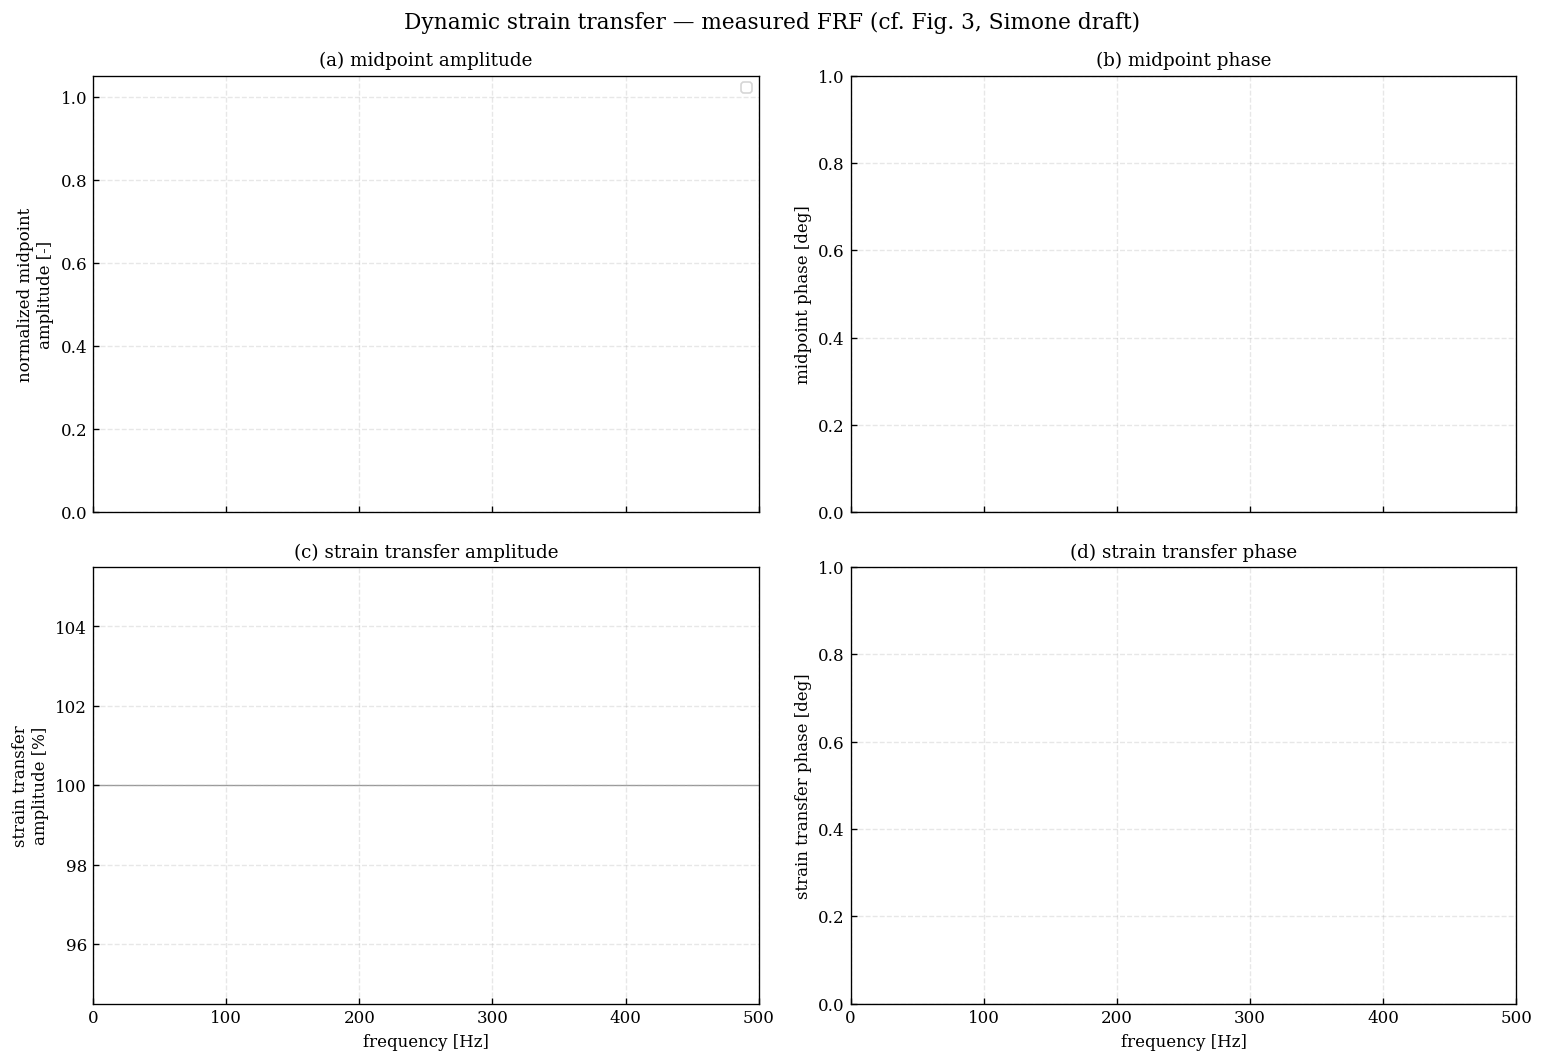

In [5]:
F_MAX_PLOT = 500.0

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=False, show_eta_pred=True,
                            phase_mode='wrapped');

In [ ]:
F_MAX_PLOT = 500.0

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=False, show_eta_pred=True,
                            phase_mode='wrapped');

---
## § 4  Estimator comparison

The processing-chapter figure: direct (single FFT, no averaging) as the noisy
baseline, H1/H2 as the noise-on-output / noise-on-input least-squares fits,
Hv as the total-least-squares compromise, and the coherence that explains
where they diverge.

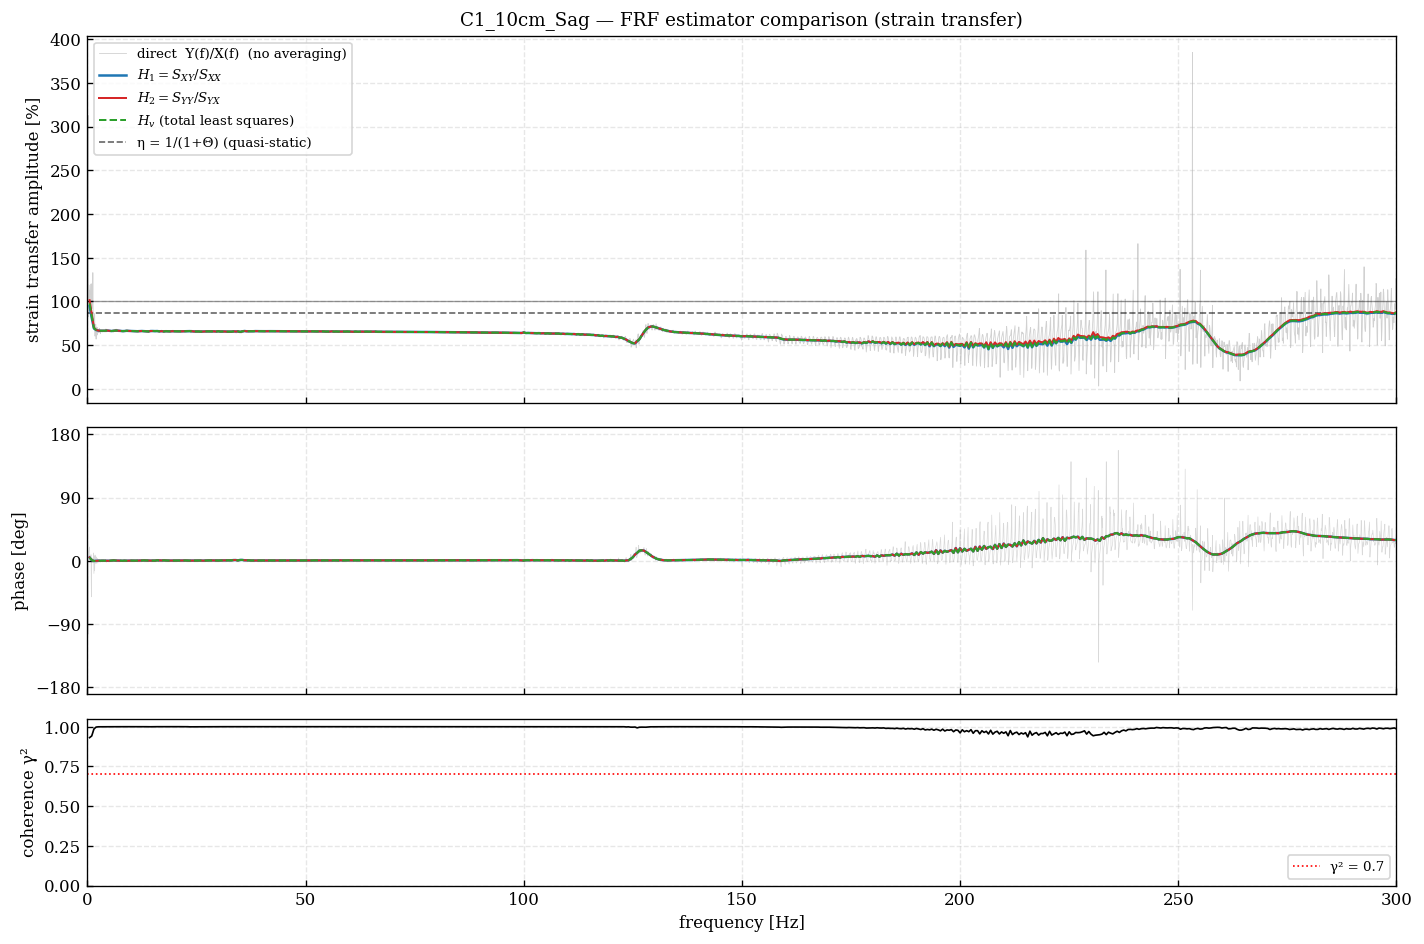

In [5]:
plotting.plot_estimator_comparison(DATASETS[1], which='eta',
                                   f_max=300.0, coh_thresh=0.7);

---
## § 5  STFT-per-frequency cross-check

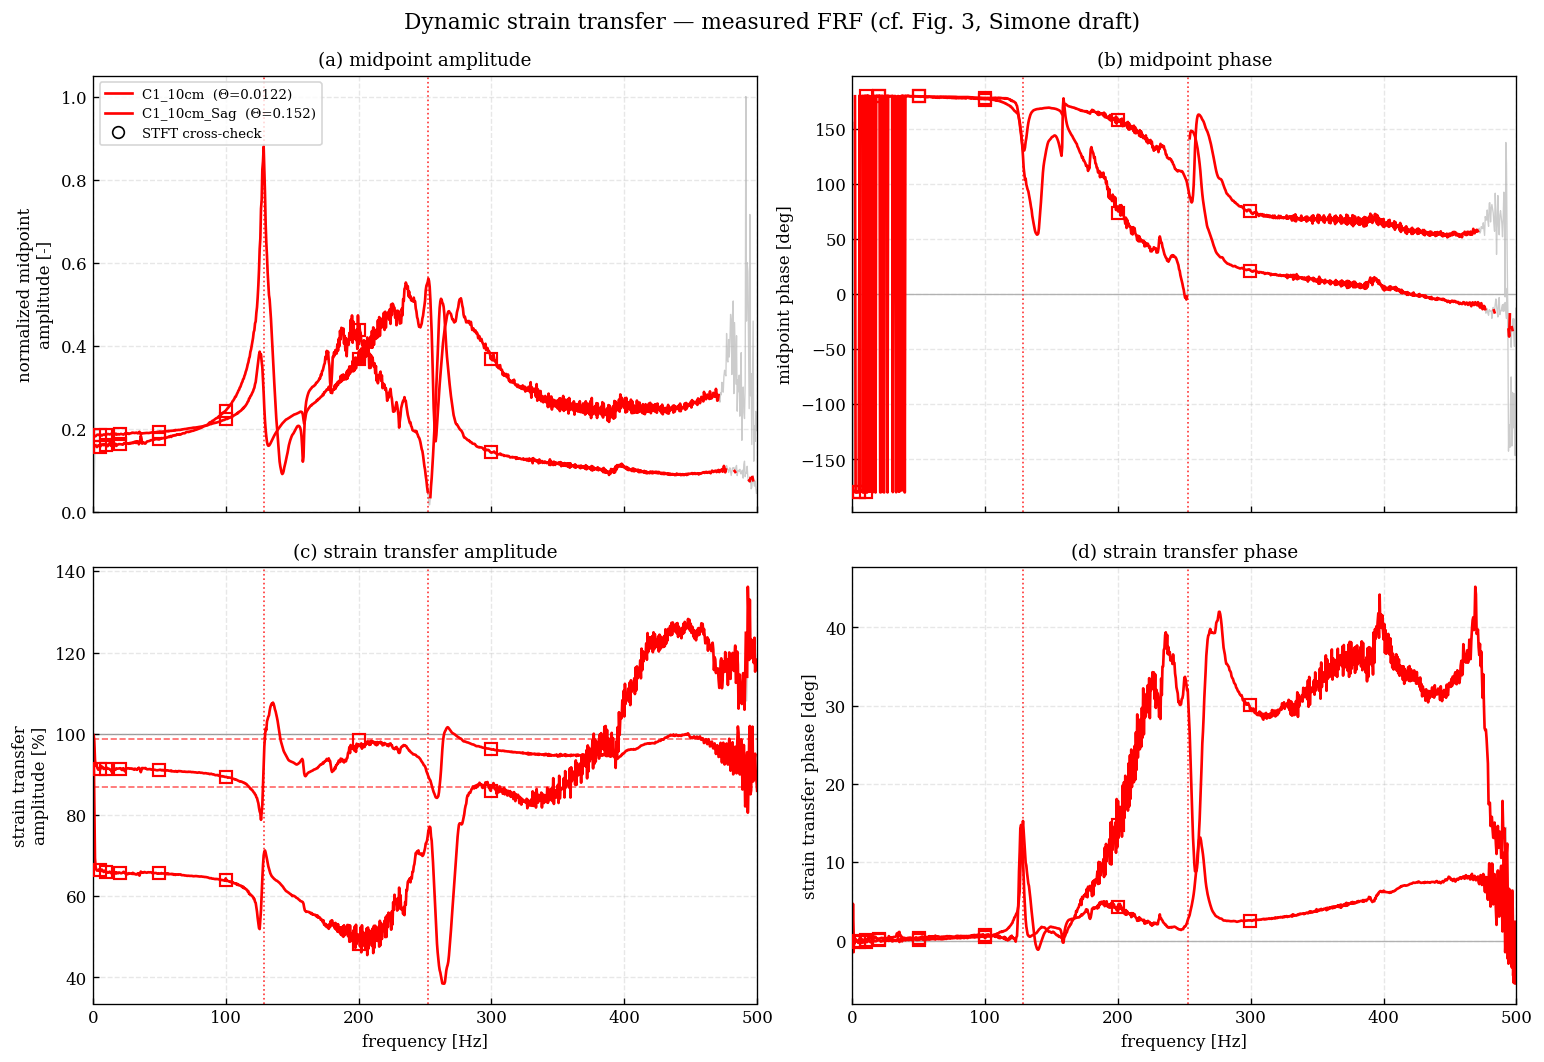

In [6]:
STFT_FREQS = [5, 10, 20, 50, 100, 200, 300]

for cfg in DATASETS:
    freqdomain.stft_point_transfers(cfg, STFT_FREQS)

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=True, show_eta_pred=True,
                            phase_mode='wrapped');

---
## § 6  η vs Θ across all configurations

Batch: for every sweep dataset compute the coherence-gated band mean
$\eta=\langle|H_\eta(f)|\rangle$ over the quasi-static band, then scatter
against Θ with the theory curve η = 1/(1+Θ).

> First run is heavy (~42 .mat loads); cached afterwards.

In [7]:
ETA_LABELS = config.SWEEP_LABELS
ETA_DATASETS = config.select_datasets(ETA_LABELS)

ETA_FMIN, ETA_FMAX, ETA_COH = 1.0, 25.0, 0.7

for cfg in ETA_DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    freqdomain.compute_transfer_functions(cfg, estimator=ESTIMATOR,
                                          all_estimators=True)
    em, es, n = freqdomain.band_mean_eta(cfg, ETA_FMIN, ETA_FMAX, ETA_COH)
    print(f"  {cfg['label']:20s} Θ={cfg['theta_pred']:.4g}  "
          f"η_meas={('%.3f' % em) if em is not None else ' n/a':>6}  (n={n})")

  C2_5cm               Θ=0.008493  η_meas= 0.997  (n=49)
  C2_5cm_Sag           Θ=0.008939  η_meas= 1.001  (n=49)
  C2_10cm              Θ=0.02078  η_meas= 1.013  (n=49)
  C2_10cm_Sag          Θ=0.03614  η_meas= 0.998  (n=49)
  C2_15cm              Θ=0.03798  η_meas= 0.918  (n=49)
  C2_15cm_Sag          Θ=0.1364  η_meas= 0.835  (n=49)
  C2_20cm              Θ=0.07216  η_meas= 0.933  (n=49)
  C2_20cm_Sag          Θ=0.1305  η_meas= 0.815  (n=49)
  C3_5cm               Θ=0.004749  η_meas= 0.997  (n=49)
  C3_5cm_Sag           Θ=0.07104  η_meas= 0.937  (n=49)
  C3_10cm              Θ=0.006788  η_meas= 0.964  (n=18)
  C3_10cm_Sag          Θ=0.06012  η_meas= 0.845  (n=49)
  C3_15cm              Θ=0.01024  η_meas= 0.981  (n=49)
  C3_15cm_Sag          Θ=0.1853  η_meas= 0.743  (n=49)
  C3_20cm              Θ=0.06525  η_meas= 0.853  (n=49)
  C3_20cm_Sag          Θ=0.3336  η_meas= 0.996  (n=36)
  C4_5cm               Θ=0.006576  η_meas= 0.970  (n=49)
  C4_5cm_Sag           Θ=0.00631  η_meas= 0.936

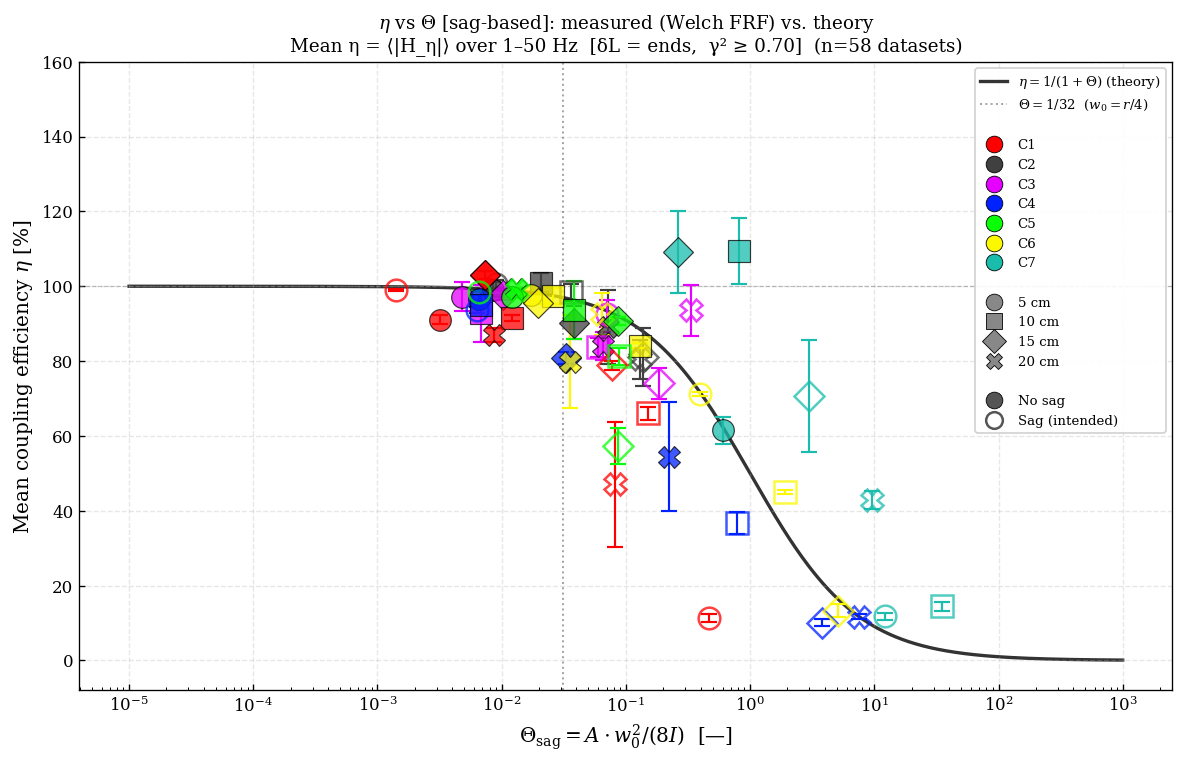

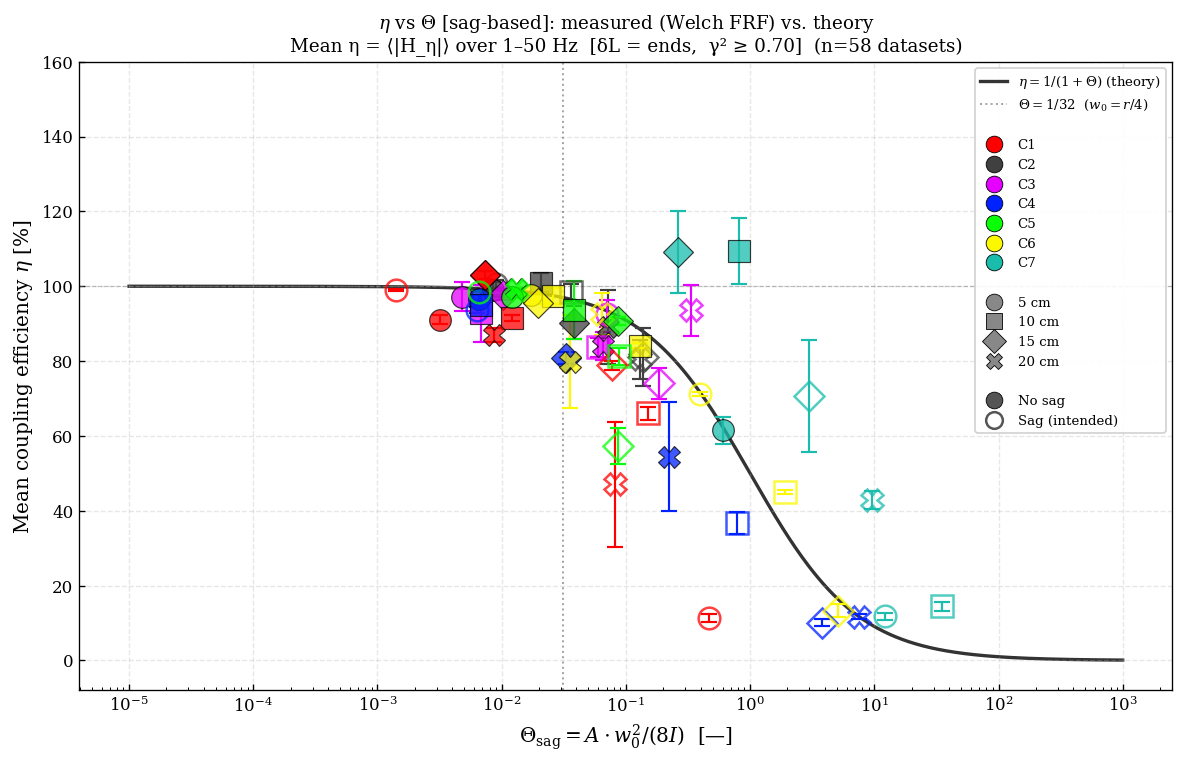

In [20]:
ETA_FMIN, ETA_FMAX, ETA_COH = 1.0, 50.0, 0.7
plotting.plot_eta_vs_theta_fd(
    ETA_DATASETS, f_min=ETA_FMIN, f_max=ETA_FMAX, coh_thresh=ETA_COH,
    theta_source='sag', x_source=X_SOURCE, percent=True)

# theta_source='material' uses Θ from ρ, E instead of the measured sag.;

---
## § 7  Export

- `freqdomain_eta.npz` — one row per configuration: Θ (both sources),
  η_pred, coherence-gated band-mean η for **each estimator** (h1/h2/hv).
- `freqdomain_frf.npz` — full FRF curves (|H|, wrapped phase, γ²) for the
  datasets selected in § 1, for the paper FRF figure.

In [ ]:
# band_mean_frf is grid-aware: the h1/h2/hv variants always live on the Welch
# grid even when the primary FRF is the direct one, so they must not be paired
# with tf['f'] by hand.

acc = dict(labels=[], cable=[], gap_m=[], is_sag_variant=[],
           theta_sag=[], theta_material=[], theta_material_std=[],
           eta_pred=[], f1_meas=[],
           eta_primary=[], eta_primary_std=[],
           eta_h1=[], eta_h1_std=[], eta_h2=[], eta_h2_std=[],
           eta_hv=[], eta_hv_std=[], n_bins=[])
for cfg in ETA_DATASETS:
    tf = cfg['fd_tf']
    acc['labels'].append(cfg['label'])
    acc['cable'].append(cfg['cable'])
    acc['gap_m'].append(cfg['gap_m'])
    acc['is_sag_variant'].append('Sag' in cfg['label'])
    acc['theta_sag'].append(cfg['theta_pred'])
    acc['theta_material'].append(cfg['theta_material'])
    acc['theta_material_std'].append(cfg['theta_material_std'])
    acc['eta_pred'].append(cfg['eta_pred'])
    res = cfg.get('fd_resonance') or {}
    acc['f1_meas'].append(res.get('f1_meas', np.nan))
    # Primary FRF (whatever ESTIMATOR selected — 'direct' included)
    m, s, n = freqdomain.band_mean_frf(tf, 'H_eta', ETA_FMIN, ETA_FMAX, ETA_COH)
    acc['eta_primary'].append(m)
    acc['eta_primary_std'].append(s)
    acc['n_bins'].append(n)
    # Averaged estimators for comparison (always on the Welch grid)
    for est in ('h1', 'h2', 'hv'):
        m, s, _ = freqdomain.band_mean_frf(tf, f'H_eta_{est}',
                                           ETA_FMIN, ETA_FMAX, ETA_COH)
        acc[f'eta_{est}'].append(m)
        acc[f'eta_{est}_std'].append(s)

acc['is_sag_variant'] = np.array(acc['is_sag_variant'])
export.export_results(
    'freqdomain_eta',
    meta=dict(band=(ETA_FMIN, ETA_FMAX), coh_thresh=ETA_COH,
              x_source=X_SOURCE, estimator_primary=tf['estimator']),
    **acc)

In [ ]:
# FRF curves of the § 1 selection.
# f is the primary grid (dense FFT for ESTIMATOR=None, Welch otherwise);
# f_welch is the grid the H_eta_h2/hv variants live on.
tf0 = DATASETS[0]['fd_tf']
export.export_results(
    'freqdomain_frf',
    meta=dict(x_source=X_SOURCE, estimator=tf0['estimator'], grid=tf0['grid'],
              nperseg=tf0['nperseg'], df=tf0['df'], coh_thresh=0.7),
    labels=[c['label'] for c in DATASETS],
    theta=[c['theta_pred'] for c in DATASETS],
    eta_pred=[c['eta_pred'] for c in DATASETS],
    f1_meas=[c['fd_resonance']['f1_meas'] for c in DATASETS],
    f=tf0['f'],
    H_eta_abs=[np.abs(c['fd_tf']['H_eta']) for c in DATASETS],
    H_eta_phase=[np.angle(c['fd_tf']['H_eta']) for c in DATASETS],
    coh_eta=[c['fd_tf']['coh_eta'] for c in DATASETS],
    H_mid_abs=[np.abs(c['fd_tf']['H_mid']) for c in DATASETS],
    H_mid_phase=[np.angle(c['fd_tf']['H_mid']) for c in DATASETS],
    coh_mid=[c['fd_tf']['coh_mid'] for c in DATASETS],
    f_welch=tf0['f_welch'],
    H_eta_h2_abs=[np.abs(c['fd_tf']['H_eta_h2']) for c in DATASETS],
    H_eta_hv_abs=[np.abs(c['fd_tf']['H_eta_hv']) for c in DATASETS],
)